In [2]:
!pip install -q langgraph
!pip install -q langchain
!pip install -q langchain-community
!pip install -q langchain-openai
!pip install -q chromadb
!pip install -q pypdf
!pip install -q pandas
!pip install -q reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

In [3]:
!pip install -q sentence-transformers

In [4]:
import os,re
import json
import pandas as pd
import logging
import ast

from typing import TypedDict

from pypdf import PdfReader

from langgraph.graph import StateGraph, END

from langchain_openai import ChatOpenAI
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma

from reportlab.platypus import SimpleDocTemplate
from reportlab.platypus import Paragraph
from reportlab.lib.styles import getSampleStyleSheet


/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
/tmp/ipykernel_2700/4019239098.py:14: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings


In [ ]:
os.environ["OPENROUTER_API_KEY"] = ""

llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1"
)

In [6]:
embedding_model = HuggingFaceEmbeddings(

    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

print("Embedding Model Ready")

/tmp/ipykernel_2700/486711094.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding Model Ready


In [53]:
from reportlab.platypus import SimpleDocTemplate, Paragraph
from reportlab.lib.styles import getSampleStyleSheet

loan_application_text = """
LOAN APPLICATION FORM

Application ID: APP001

PERSONAL DETAILS
-------------------------
Customer Name: 	Charvi Koshy
Age: 32
Phone Number: 9876543210
Email: rajeshkumar@gmail.com
Address: Chennai, Tamil Nadu

LOAN DETAILS
-------------------------
Loan Type: Home Loan
Loan Amount Requested: ₹25,00,000
Loan Tenure: 20 Years

EMPLOYMENT DETAILS
-------------------------
Employment Type: Salaried
Company Name: Infosys
Designation: Software Engineer
Work Experience: 7 Years

INCOME DETAILS
-------------------------
Monthly Income: ₹1,20,000

BANK DETAILS
-------------------------
Bank Name: SBI
Account Type: Savings

DECLARATION
-------------------------
I hereby declare that the information provided is true to the best of my knowledge.
"""

styles = getSampleStyleSheet()

pdf = SimpleDocTemplate("loan_application.pdf")

# Preserve line breaks
formatted_text = loan_application_text.replace("\n", "<br/>")

content = [
    Paragraph(formatted_text, styles['BodyText'])
]

pdf.build(content)

print("Loan Application PDF Created")

Loan Application PDF Created


In [39]:
from reportlab.platypus import SimpleDocTemplate, Paragraph
from reportlab.lib.styles import getSampleStyleSheet

policy_text = """
==================================================
ENTERPRISE BANK LOAN ELIGIBILITY POLICY
VERSION 2.0
==================================================

PURPOSE
--------------------------------------------------

This policy defines the official rules and decision
criteria used by the Enterprise Bank AI Loan
Eligibility Assessment System for evaluating
loan applications.

The policy ensures:
- consistent decision-making,
- financial risk control,
- explainable AI recommendations,
- regulatory compliance,
- deterministic approval workflows.

All decisions generated by the AI system MUST
strictly follow this policy document.


==================================================
SECTION 1 — CREDIT SCORE POLICY
--------------------------------------------------

1. Credit score >= 750
   - Applicant is considered financially strong.
   - Eligible for fast-track approval consideration.
   - Indicates strong repayment reliability.

2. Credit score between 650 and 749
   - Applicant is considered moderate risk.
   - Requires detailed financial evaluation.
   - Additional repayment analysis may be required.

3. Credit score between 550 and 649
   - Applicant is considered high risk.
   - Mandatory human review is required.
   - Approval is not guaranteed.

4. Credit score below 550
   - Applicant is considered severely high risk.
   - Application MUST be rejected immediately.
   - Human review conditions do NOT apply.


==================================================
SECTION 2 — DEBT-TO-INCOME (DTI) POLICY
--------------------------------------------------

Debt-To-Income Ratio Formula:

DTI = ((Monthly Expenses + Existing EMI)
       / Monthly Income) * 100

1. DTI ratio below 40 percent
   - Financial burden is considered healthy.
   - Applicant demonstrates good repayment capacity.

2. DTI ratio between 40 and 60 percent
   - Applicant is considered moderate financial risk.
   - Requires additional affordability evaluation.

3. DTI ratio between 60 and 75 percent
   - Applicant is financially overburdened.
   - Mandatory human review is required.

4. DTI ratio above 75 percent
   - Applicant is considered financially unstable.
   - Application MUST be rejected immediately.
   - Human review conditions do NOT apply.


==================================================
SECTION 3 — FRAUD RISK POLICY
--------------------------------------------------

1. Any confirmed fraud indicator
   MUST result in immediate rejection.

2. Fraud investigation pending
   MUST trigger mandatory human review.

3. Fraud-related rejection conditions
   override all approval conditions.

4. Applications with confirmed fraud
   cannot qualify for automated approval.


==================================================
SECTION 4 — REPAYMENT HISTORY POLICY
--------------------------------------------------

1. Excellent repayment history
   - Strong positive approval factor.
   - Indicates stable financial discipline.

2. Average repayment history
   - Requires moderate financial review.
   - Approval depends on other financial indicators.

3. Poor repayment history
   - Considered major risk factor.
   - Mandatory human review required.

4. Repeated missed EMI payments
   - Considered severe repayment instability.
   - Application MUST be rejected immediately.


==================================================
SECTION 5 — PREVIOUS LOAN DEFAULT POLICY
--------------------------------------------------

1. No previous defaults
   - Positive approval indicator.

2. One previous default
   - Moderate risk indicator.
   - Requires additional financial evaluation.

3. Two previous defaults
   - High risk indicator.
   - Mandatory human review required.

4. Three or more previous defaults
   - Considered repeated default behavior.
   - Application MUST be rejected immediately.


==================================================
SECTION 6 — SAVINGS AND ACCOUNT BALANCE POLICY
--------------------------------------------------

1. Strong savings balance
   improves financial stability assessment.

2. Stable account balance history
   positively impacts repayment confidence.

3. Extremely low savings combined with
   high EMI burden increases default risk.

4. Savings balance alone CANNOT override
   rejection conditions.


==================================================
SECTION 7 — LOAN AMOUNT POLICY
--------------------------------------------------

1. Loan amount must be reasonable relative
   to applicant income and repayment capacity.

2. High-value loan requests require enhanced
   affordability assessment.

3. Loan requests significantly exceeding
   repayment capability MUST trigger
   human review or rejection depending
   on financial risk severity.

4. Loan amount approval depends on:
   - repayment capacity,
   - DTI ratio,
   - existing liabilities,
   - credit behavior.


==================================================
SECTION 8 — AUTOMATED APPROVAL CONDITIONS
--------------------------------------------------

Applications qualify for AUTOMATED APPROVAL
ONLY if ALL conditions below are satisfied:

- Credit score >= 750
- DTI ratio below 40 percent
- No fraud indicators
- No previous defaults
- Stable repayment history
- Acceptable repayment capability
- No policy violations

If ANY condition above is not satisfied,
automated approval MUST NOT occur.


==================================================
SECTION 9 — HUMAN REVIEW CONDITIONS
--------------------------------------------------

Applications require HUMAN REVIEW
ONLY if ALL rejection conditions are FALSE
AND one or more of the following conditions exist:

- Credit score between 550 and 649
- DTI ratio between 60 and 75 percent
- Pending fraud investigation
- Two previous defaults
- Poor repayment history
- Borderline financial stability
- Moderate affordability concerns

Human review conditions MUST NOT override
rejection conditions.


==================================================
SECTION 10 — REJECTION CONDITIONS
--------------------------------------------------

Applications MUST be REJECTED immediately
if ANY of the following conditions are satisfied:

- Confirmed fraud activity exists
- Credit score below 550
- DTI ratio above 75 percent
- Repeated missed EMI payments exist
- Three or more previous defaults exist
- Severe repayment instability exists
- Financial profile indicates
  inability to repay loan obligations

Rejection conditions have the HIGHEST priority
in the decision hierarchy.

If rejection conditions are satisfied:
- human review MUST NOT occur
- automated approval MUST NOT occur


==================================================
SECTION 11 — DECISION PRIORITY HIERARCHY
--------------------------------------------------

The AI system MUST follow the exact
decision hierarchy below:

PRIORITY 1 — REJECTION
- Rejection conditions override ALL other rules.

PRIORITY 2 — HUMAN REVIEW
- Applied only if rejection conditions are FALSE.

PRIORITY 3 — AUTOMATED APPROVAL
- Applied only if both rejection and
  human review conditions are FALSE.

This hierarchy guarantees deterministic
and consistent loan decisions.


==================================================
SECTION 12 — AI SYSTEM BEHAVIOR RULES
--------------------------------------------------

1. The AI system MUST provide explainable
   reasoning for every recommendation.

2. All recommendations MUST reference
   financial indicators and policy rules.

3. The AI system MUST NOT generate
   random or unsupported decisions.

4. The AI system MUST follow deterministic
   policy hierarchy rules.

5. The AI system MUST NOT override
   rejection conditions using positive
   financial indicators.

6. Human review cases require manual
   verification before final approval.


==================================================
END OF POLICY DOCUMENT
==================================================
"""

styles = getSampleStyleSheet()

pdf = SimpleDocTemplate("loan_policy.pdf")

# Preserve line breaks
formatted_text = policy_text.replace("\n", "<br/>")

content = [
    Paragraph(formatted_text, styles['BodyText'])
]

pdf.build(content)

print("Loan Policy PDF Created")

Loan Policy PDF Created


In [13]:
df = pd.read_csv("/content/improved_loan_customer_dataset.csv", encoding='latin1')

print(df.head())

  application_id  customer_name  age  monthly_income  monthly_expenses  \
0         APP001   Aayush Barad   30           36556             46048   
1         APP002  Nehmat Thakur   57          139974             38893   
2         APP003   Aayush Wason   29          124104             55082   
3         APP004       Veer Sem   27           42012             39871   
4         APP005      Sana Tank   40          213977             19358   

   existing_emi employment_type  customer_since_years  credit_score  \
0         16049        Salaried                     3           602   
1         29439  Business Owner                     5           553   
2         39565   Self-employed                    13           572   
3         18965        Salaried                    14           669   
4         39920  Business Owner                     3           823   

   previous_defaults  active_loans_count  savings_balance  account_balance  \
0                  0                   4          

In [14]:
loader = PyPDFLoader("loan_policy.pdf")

pages = loader.load()

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

chunks = splitter.split_documents(pages)

vector_db = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model
)

retriever = vector_db.as_retriever()

print("Vector Database Created")


Vector Database Created


In [15]:
logging.basicConfig(
    filename="loan_system.log",
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
    force=True # Ensures basicConfig is re-run even if handlers exist
)


def log_event(message):
    logging.info(message)
    print(message)

In [16]:
class LoanState(TypedDict):
    loan_text: str
    customer_name: str
    loan_amount_requested: int
    loan_purpose: str
    monthly_income: int
    monthly_expenses: int
    existing_emi: int
    credit_score: int
    savings_balance: int
    account_balance: int
    previous_defaults: int
    active_loans_count: int
    fraud_flag: str
    repayment_history: str
    financial_status: str
    dti_ratio: float
    risk_level: str
    risk_reason: str
    policy_context: str
    recommendation: str
    final_decision: str

In [17]:
def clean_json_response(response_text):

    cleaned = re.sub(
        r"```json|```python|```",
        "",
        response_text
    ).strip()
    print(cleaned)
    return ast.literal_eval(cleaned)

In [18]:
def parse_pdf(file_path):

    reader = PdfReader(file_path)

    text = ""

    for page in reader.pages:
        text += page.extract_text()

    return text


In [19]:
def retrieve_policy(query):

    docs = retriever.invoke(query)

    if not docs:
        return "No policy found"

    return docs[0].page_content


In [20]:
def extraction_agent(state):

    log_event("Extraction Agent Started")

    text = state["loan_text"]

    prompt = f"""
    Extract the following fields from this loan application.

    Return ONLY python dictionary format.

    Fields:
    customer_name
    loan_amount_requested
    loan_purpose
    monthly_income

    Loan Application:

    {text}"""

    response = llm.invoke(prompt)
    print(response)
    extracted = clean_json_response(response.content)

    log_event("Extraction Completed")

    return extracted


In [21]:
def customer_lookup_agent(state):

    print("Customer Lookup Agent Started")

    customer_name = state["customer_name"]

    result = df[
        df["customer_name"] == customer_name
    ]

    if result.empty:

        print("Customer not found")

        return {}

    customer_data = result.iloc[0].to_dict()

    print("Customer Data Retrieved")

    return customer_data

In [22]:
from langchain.tools import tool

@tool
def financial_calculation_tool(income: int,expenses: int,emi: int,savings_balance: int):

    """Calculates financial metrics for loan eligibility analysis."""

    dti = ((expenses + emi) / income) * 100

    disposable_income = (
        income - expenses - emi
    )

    savings_ratio = (
        savings_balance / income
    )

    return {

        "dti_ratio": round(dti, 2),

        "disposable_income":
        disposable_income,

        "savings_ratio":
        round(savings_ratio, 2)
    }

In [23]:
def financial_agent(state):

    print("Financial Agent Started")

    metrics = financial_calculation_tool.invoke({

        "income":
        state["monthly_income"],

        "expenses":
        state["monthly_expenses"],

        "emi":
        state["existing_emi"],

        "savings_balance":
        state["savings_balance"]
    })

    dti = metrics["dti_ratio"]

    if dti < 40:

        status = "Healthy"

    elif dti < 60:

        status = "Moderate"

    else:

        status = "Risky"

    return {

        **metrics,

        "financial_status": status
    }

In [24]:
def risk_agent(state):

    log_event("Risk Agent Started")

    prompt = f"""
You are an enterprise banking risk assessment AI system.

Your task is to evaluate the financial and repayment risk
of a loan applicant based on banking and credit indicators.

Carefully analyze the applicant using:

1. Credit Score
2. Previous Loan Defaults
3. Fraud Indicators
4. Existing EMI Burden
5. Monthly Income
6. Repayment History

Risk Classification Guidelines:

- LOW RISK:
  Strong credit profile, stable repayment behavior,
  low financial burden, no fraud concerns.

- MEDIUM RISK:
  Moderate financial burden, average credit profile,
  minor repayment concerns.

- HIGH RISK:
  Poor credit score, previous defaults,
  fraud indicators, unstable repayment behavior,
  or excessive financial burden.

Applicant Information:

Credit Score:
{state['credit_score']}

Previous Defaults:
{state['previous_defaults']}

Fraud Flag:
{state['fraud_flag']}

Existing EMI:
{state['existing_emi']}

Monthly Income:
{state['monthly_income']}

Repayment History:
{state['repayment_history']}

Instructions:

- Perform careful financial risk reasoning.
- Explain WHY the applicant belongs to the selected risk category.
- Keep explanation concise but meaningful.
- Do NOT generate markdown.
- Do NOT generate code blocks.
- Return ONLY a valid Python dictionary.

Expected Output Format:

{{
    "risk_level": "Low/Medium/High",
    "risk_reason": "Clear explanation of risk assessment"
}}
"""

    response = llm.invoke(prompt)

    risk_output = clean_json_response(response.content)

    log_event("Risk Analysis Completed")

    return risk_output


In [25]:
def policy_rag_agent(state):

    log_event("Policy Retrieval Started")

    query = f"""
    Loan policy for:

    Risk Level = {state['risk_level']}

    Financial Status = {state['financial_status']}
    """

    policy = retrieve_policy(query)

    log_event("Policy Retrieved")

    return {
        "policy_context": policy
    }


In [44]:
def recommendation_agent(state):

    prompt = f"""
You are an Enterprise AI Loan Eligibility
Assessment System.

Your responsibility is to analyze
the applicant profile and generate:

1. Loan Summary
2. Risk Explanation
3. Eligibility Recommendation
4. Final Decision

You MUST strictly follow
the provided bank policy document.

You MUST NOT invent new rules,
override policy conditions,
or generate unsupported decisions.

--------------------------------------------------
APPLICANT FINANCIAL PROFILE
--------------------------------------------------

Monthly Income:
{state['monthly_income']}

Credit Score:
{state['credit_score']}

DTI Ratio:
{state['dti_ratio']}

Risk Level:
{state['risk_level']}

Risk Explanation:
{state['risk_reason']}

Previous Defaults:
{state['previous_defaults']}

Fraud Flag:
{state['fraud_flag']}

Repayment History:
{state['repayment_history']}

--------------------------------------------------
BANK POLICY DOCUMENT
--------------------------------------------------

{state['policy_context']}

--------------------------------------------------
INSTRUCTIONS
--------------------------------------------------

1. Carefully analyze the applicant.

2. Strictly follow the policy hierarchy
   and decision rules defined in the
   policy document.

3. Ensure the final decision is fully
   aligned with policy conditions.

4. Explain WHY the applicant qualifies
   for the selected decision.

5. Do NOT generate random decisions.

--------------------------------------------------
OUTPUT REQUIREMENTS
--------------------------------------------------

- Return ONLY valid Python dictionary
- Do NOT generate markdown
- Do NOT generate code blocks
- Do NOT generate explanations
  outside the dictionary

Final decision MUST be EXACTLY one of:

- APPROVED
- REJECTED
- HUMAN REVIEW REQUIRED

Expected Output Format:

{{
    "loan_summary": "...",
    "risk_explanation": "...",
    "eligibility_recommendation": "...",
    "decision": "APPROVED/REJECTED/HUMAN REVIEW REQUIRED"
}}
"""
    response = llm.invoke(prompt)

    result = clean_json_response(response.content)

    return {
        "recommendation": result
    }

In [27]:
def router(state):

    decision = state["recommendation"]["decision"]

    if decision == "HUMAN REVIEW REQUIRED":
        return "human_review"

    return "final_approval"

In [28]:
def human_review_agent(state):

    log_event("Human Review Triggered")

    return {
        "final_decision": "Pending Human Review"
    }


In [29]:
def final_approval_agent(state):

    log_event("Final Approval Agent Started")

    recommendation = state["recommendation"]["decision"]

    if "APPROVE" in recommendation:
        decision = "APPROVED"

    elif "CONDITIONAL" in recommendation:
        decision = "CONDITIONALLY APPROVED"

    elif "REJECT" in recommendation:
        decision = "REJECTED"

    else:
        decision = "UNKNOWN"

    return {
        "final_decision": decision
    }


In [30]:
def validation_agent(state):

    print("Validation Agent Started")

    errors = []

    if state["credit_score"] < 300 or state["credit_score"] > 900:
        errors.append("Invalid credit score")

    if state["monthly_income"] <= 0:
        errors.append("Invalid income")

    if state["dti_ratio"] < 0:
        errors.append("Invalid DTI ratio")

    if errors:

        return {
            "final_decision":
            f"Validation Failed: {errors}"
        }

    return {}

In [45]:
workflow = StateGraph(LoanState)

workflow.add_node("extraction_agent",extraction_agent)
workflow.add_node("customer_lookup_agent",customer_lookup_agent)
workflow.add_node("financial_agent",financial_agent)
workflow.add_node("risk_agent",risk_agent)
workflow.add_node("policy_rag_agent",policy_rag_agent)
workflow.add_node("validation_agent",validation_agent)
workflow.add_node("recommendation_agent",recommendation_agent)
workflow.add_node("human_review_agent",human_review_agent)
workflow.add_node("final_approval_agent",final_approval_agent)

workflow.set_entry_point("extraction_agent")

workflow.add_edge("extraction_agent","customer_lookup_agent")
workflow.add_edge("customer_lookup_agent","financial_agent")
workflow.add_edge("customer_lookup_agent","risk_agent")
workflow.add_edge("financial_agent","policy_rag_agent")
workflow.add_edge("risk_agent","policy_rag_agent")
workflow.add_edge("policy_rag_agent","validation_agent")
workflow.add_edge("validation_agent","recommendation_agent")

workflow.add_conditional_edges(
    "recommendation_agent",
    router,
    {
        "human_review": "human_review_agent",
        "final_approval": "final_approval_agent"
    }
)

workflow.add_edge("human_review_agent",END)
workflow.add_edge("final_approval_agent",END)

loan_app = workflow.compile()

print("Workflow Compiled Successfully")


Workflow Compiled Successfully


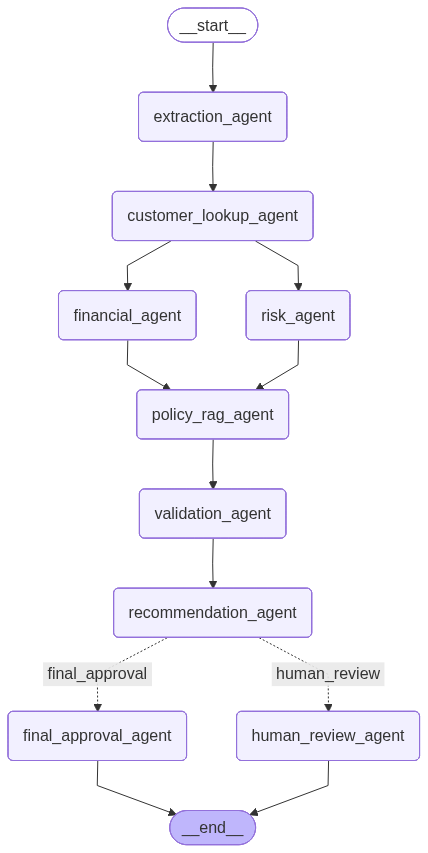

In [32]:
loan_app

In [54]:
loan_text = parse_pdf("loan_application.pdf")

initial_state = {
    "loan_text": loan_text
}

result = loan_app.invoke(initial_state)

print("\nFINAL RESULT\n")

print(result)


Extraction Agent Started
content='```python\n{\n    "customer_name": "Charvi Koshy",\n    "loan_amount_requested": "25,00,000",\n    "loan_purpose": "Home Loan",\n    "monthly_income": "1,20,000"\n}\n```' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 222, 'total_tokens': 275, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 6.51e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 6.51e-05, 'upstream_inference_prompt_cost': 3.33e-05, 'upstream_inference_completions_cost': 3.18e-05}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-4o-mini', 'system_fingerprint': 'fp_dc5460657f', 'id': 'gen-1779621909-eMfdLX0YiAoAcFLiNtLO', 'finish_reason': 'stop', 'logprobs': None} id='lc